In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(8)') 

array([2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [19]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("NP.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [20]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

Data Selection

In [21]:
#-------------------------------------------------------------------
dataset_names = ["OPAL_new","SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

df_original = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        αs = Main.alpha_s_func(μf=Q[0], μi=91.1876, αs=0.118, order=2, nf=5)
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df_original[name] = df1

91.2
91.2
59.5
53.3
43.5
34.8
29.0
29.0


Range Choice

In [45]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [46]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

df = df_original
for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        χ_lower, χ_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

59

16

16

16

16

16

16

16

In [47]:
n_replicas = 200
If_fit = True
If_scan = False

Random data

In [48]:
#np.random.seed(42)
EEC_list=[]
df_list=[]
for i in range(n_replicas):
    if If_fit == True:
        df = {}
        for name in dataset_names:
            EEC_gaussian = np.random.normal(loc=EEC[name], scale=ERROR[name])
            df[name] = pd.DataFrame({
                "CHI": χ[name], 
                "EEC": EEC_gaussian, 
                "ERROR": ERROR[name],
                "Q": Q[name],                             
                "BinSize": BinSize[name]                
                })
        df_list.append(df)
    else:
        df = {}
        for name in dataset_names:
            EEC_gaussian = EEC[name]
            df[name] = pd.DataFrame({
                "CHI": χ[name], 
                "EEC": EEC[name], 
                "ERROR": ERROR[name],
                "Q": Q[name],                             
                "BinSize": BinSize[name]                
                })
        df_list.append(df)

In [49]:
(df_list[1]["SLD"]["EEC"]-df_list[0]["SLD"]["EEC"])/df_list[0]["SLD"]["ERROR"]

0     1.881591
1     0.359546
2     1.055989
3    -1.090653
4     0.209701
5    -0.352910
6    -0.849075
7     1.100687
8    -0.576931
9     0.721573
10    0.113870
11   -0.064380
12    2.532621
13   -0.717680
14   -0.574186
15    0.360255
dtype: float64

Random ratios

In [50]:
def custom_random():
    n = np.random.uniform(1.0, 2.0)  
    if np.random.rand() < 0.5:
        return n  
    else:
        return 1 / n  

def random_ratios(n):
    ratio_matrix = pd.DataFrame(columns=['μH_ratio', 'μJ_ratio', 'νJ_ratio'])
    
    while len(ratio_matrix) < n:
        
        if If_scan == True:
            μH_ratio, μJ_ratio, νJ_ratio = custom_random(), custom_random(), custom_random()
        else:
            μH_ratio, μJ_ratio, νJ_ratio = 1.0, 1.0, 1.0

        ratio_matrix.loc[len(ratio_matrix)] = [μH_ratio, μJ_ratio, νJ_ratio]
    
    return ratio_matrix

In [51]:
ratios = random_ratios(n_replicas)
n = len(ratios)

In [52]:
display(ratios)

,μH_ratio,μJ_ratio,νJ_ratio
0,1.0,1.0,1.0
1,1.0,1.0,1.0
2,1.0,1.0,1.0
3,1.0,1.0,1.0
4,1.0,1.0,1.0
...,...,...,...
195,1.0,1.0,1.0
196,1.0,1.0,1.0
197,1.0,1.0,1.0
198,1.0,1.0,1.0


Chi-Square calculation

In [53]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

Define Objective

In [54]:
def objective(params, df, ratio_list):

    #----------
    XLL = 2 #1 for NLL
    #----------

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = params[1:]

    dataset_names = df.keys()

    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs
        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Qlist=np.array(df[name]["Q"]), 
                                        order=XLL, params=parameters, 
                                        μJ_ratio=float(ratio_list["μJ_ratio"]), μH_ratio=float(ratio_list["μH_ratio"])
                                        )                
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/N_total

Define minimization related

In [55]:
import sys

class ProgressCallback:
    def __init__(self, df, ratio_list):
        self.df = df
        self.dataset_names = dataset_names
        self.ratio_list = ratio_list

    def __call__(self, params):
        chi2_bydof = objective(params, self.df, self.ratio_list)
        sys.stdout.flush()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [56]:
initial_params = [0.118, 0.886, 2.67, 1.09]
ratio_list = pd.Series({"μJ_ratio":1.0, "μH_ratio":1.0})
objective(initial_params, df_truncated, ratio_list)
# [0.118, 0.886, 2.67, 1.09]	

2.222465291222104

Minimization

In [57]:
results_df = pd.DataFrame(columns=['αs', 'params','chi2/dof'])

bounds = [ [0.118 , 0.118], # αs
           #[-1.0 , 1.0  ], # Ω1
            [0.0, 5.0  ], # a1
            [0.0, 5.0  ], # a2
            [0.0, 5.0  ], # a3         
        ]

for i in tqdm(range(n_replicas)): 
    
    #Ratios
    ith_row = ratios.iloc[i]
    μH_ratio = ith_row['μH_ratio']    
    μJ_ratio = ith_row['μJ_ratio']
    νJ_ratio = ith_row['νJ_ratio']

    ratio_list={}
    ratio_list["μH_ratio"]=μH_ratio
    ratio_list["μJ_ratio"]=μJ_ratio
    ratio_list["νJ_ratio"]=νJ_ratio

    #Fit
    bounds_T = [list(t) for t in zip(*bounds)]

    progress_callback = ProgressCallback(df_list[i], ratio_list)

    minimizer_kwargs = {
        "method": "L-BFGS-B",
        "bounds": bounds,
        "args": (df_list[i], ratio_list),
        "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-6)},
        "callback": progress_callback
    }

    result = basinhopping(
        objective,
        initial_params,
        minimizer_kwargs=minimizer_kwargs,
        niter=0,
        accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
    )

#-----------------------------------------------------------------------------

    optimal = np.round(result.x,5)
    chi2_per_dof = result.fun

    optimal_params = optimal[1:]

    new_row = pd.Series({
        'αs': optimal[0], 
        'params': optimal_params, 
        'chi2/dof': result.fun,
    })
    results_df = pd.concat([results_df, new_row.to_frame().T], ignore_index=True)
    #print(results_df)

display(results_df)

100%|██████████| 200/200 [1:32:05<00:00, 27.63s/it]


,αs,params,chi2/dof
0,0.118,"[0.88316, 2.68625, 1.08546]",3.061643
1,0.118,"[0.88662, 2.66947, 1.09454]",3.141964
2,0.118,"[0.88508, 2.7039, 1.09529]",3.084515
3,0.118,"[0.88524, 2.7197, 1.08975]",3.441212
4,0.118,"[0.88818, 2.6179, 1.08012]",3.2474
...,...,...,...
195,0.118,"[0.88433, 2.71012, 1.09244]",3.393602
196,0.118,"[0.88463, 2.69888, 1.09429]",3.217444
197,0.118,"[0.8835, 2.66979, 1.08869]",3.496776
198,0.118,"[0.88638, 2.74422, 1.09615]",3.223352


Store Result to a File

In [58]:
results_df.to_csv("result//fit_2.csv", index=False)

In [59]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000025b9b523e10>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

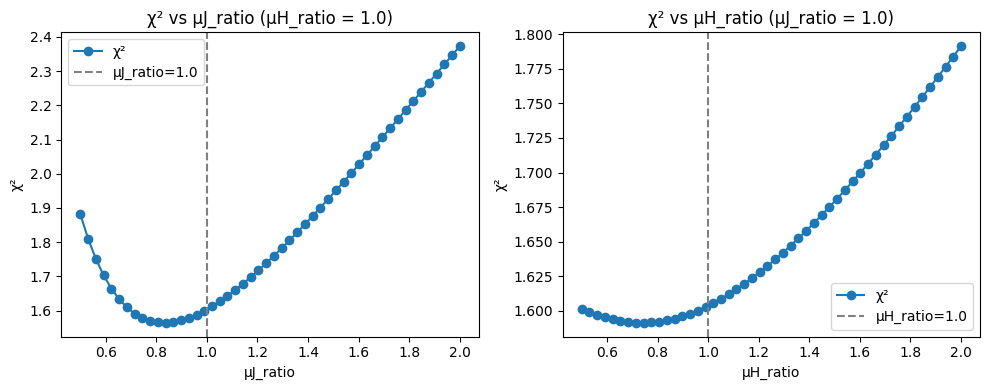

In [22]:
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

muJ_vals = np.linspace(0.5, 2.0, 50)
muH_vals = np.linspace(0.5, 2.0, 50)

muJ_chi2 = np.empty_like(muJ_vals)
muH_chi2 = np.empty_like(muH_vals)

for i, μJ in enumerate(muJ_vals):
    ratios = pd.Series({"μJ_ratio": μJ, "μH_ratio": 1.0})
    chi2 = objective(initial_params, df_truncated, ratios)
    muJ_chi2[i] = chi2

for i, μH in enumerate(muH_vals):
    ratios = pd.Series({"μJ_ratio": 1.0, "μH_ratio": μH})
    chi2 = objective(initial_params, df_truncated, ratios)
    muH_chi2[i] = chi2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

ax1.plot(muJ_vals, muJ_chi2, "o-", label="χ²")
ax1.axvline(1.0, color="gray", linestyle="--", label="μJ_ratio=1.0")
ax1.set_title("χ² vs μJ_ratio (μH_ratio = 1.0)")
ax1.set_xlabel("μJ_ratio")
ax1.set_ylabel("χ²")
ax1.legend()

ax2.plot(muH_vals, muH_chi2, "o-", label="χ²")
ax2.axvline(1.0, color="gray", linestyle="--", label="μH_ratio=1.0")
ax2.set_title("χ² vs μH_ratio (μJ_ratio = 1.0)")
ax2.set_xlabel("μH_ratio")
ax2.set_ylabel("χ²")
ax2.legend()

plt.show()